In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from skimage import feature

from scipy.ndimage import rotate

In [2]:
date = "18_03_2026"

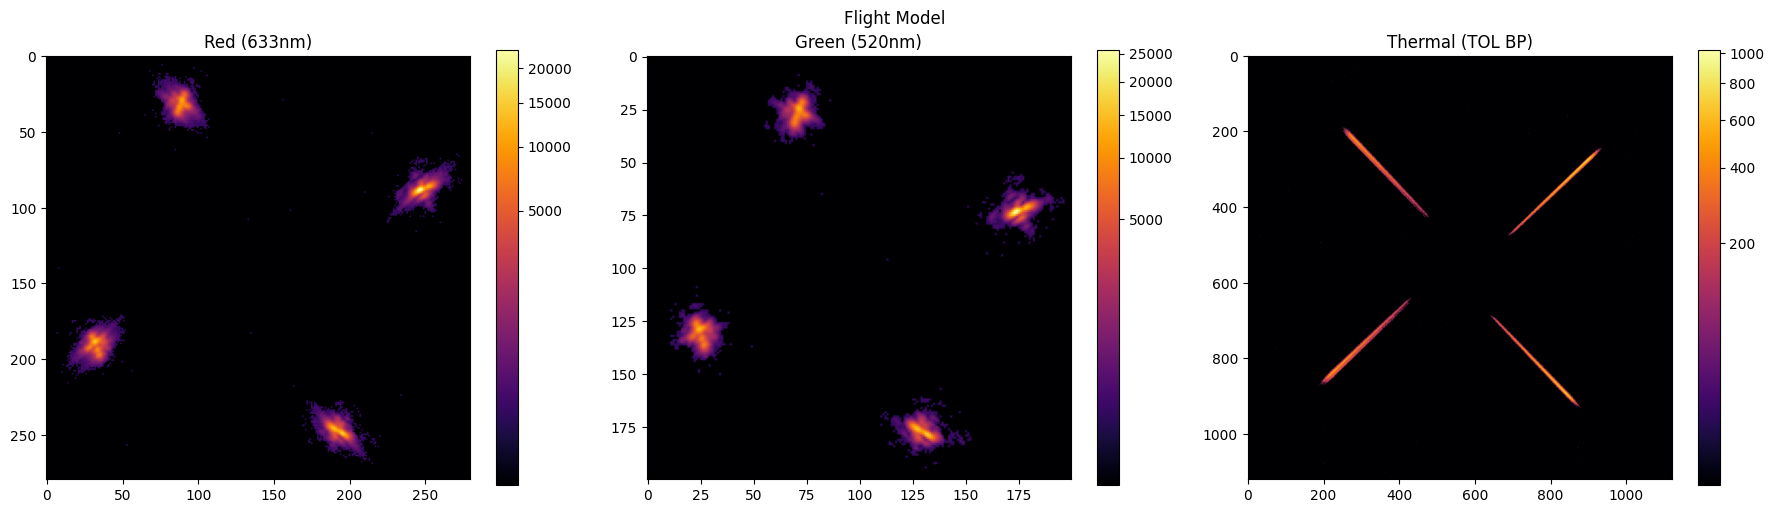

In [75]:
if date == "18_03_2026":
    fname = "/import/morgana2/gpir9156/toliman/non_glued/18_03_2026_flightmodel/"

    img_names = ["18_03_2026_red_fullframe.npy", 
                "18_03_2026_green_fullframe.npy",
                "18_03_2026_broad_fullframe.npy",
                 ]

    titles = ["Red (633nm)", "Green (520nm)", "Thermal (TOL BP)"]

    lobe_hlfsz = 300 
    b = 1200 # px
    bs = [
        1240,
        1020,
        1200,
    ]
    lobe_hlfszs = [70, 50, 280]
    env_hlfsz = 175


    plt.figure(figsize=(18,5))
    for i, img_fname in enumerate(img_names):
        frame = np.load(fname + img_fname)[1]
        psf_cen = np.unravel_index(np.argmax(eg, axis=None), eg.shape)
        lobe_offsets = [
            np.array([-bs[i],-bs[i]]),
            np.array([-bs[i],bs[i]]),
            np.array([bs[i],-bs[i]]),
            np.array([bs[i],bs[i]]),
        ]
        crops = []
        for offset in lobe_offsets:
            lobe_loc = psf_cen + offset
            crops.append(frame[lobe_loc[0]-lobe_hlfszs[i]:lobe_loc[0]+lobe_hlfszs[i], lobe_loc[1]-lobe_hlfszs[i]:lobe_loc[1]+lobe_hlfszs[i]])

        img_stitch = np.concatenate([np.concatenate(crops[0:2], axis=1), np.concatenate(crops[2:4], axis=1)], axis=0)
        # de_rot = rotate(img_stitch, 22, reshape=False)
        # det_rot_crp  = de_rot[env_hlfsz:-env_hlfsz, env_hlfsz:-env_hlfsz]

        plt.subplot(1,3,i+1)
        plt.imshow(img_stitch, norm=PowerNorm(gamma=0.3), cmap='inferno')
        plt.colorbar()
        plt.title(titles[i])


    plt.suptitle("Flight Model")
    plt.tight_layout()  
    # eg = np.load(fname + img_names[0])[0]
    # psf_cen = np.unravel_index(np.argmax(eg, axis=None), eg.shape)
    # lobe_1 = psf_cen + np.array([b,b])

    # plt.figure()
    # plt.imshow(eg, norm=PowerNorm(gamma=0.1), cmap='inferno')
    # plt.plot(psf_cen[1], psf_cen[0], "wx")
    # plt.plot(lobe_1[1], lobe_1[0], "wx")

    # plt.colorbar()
    # plt.show()